Задание 1 (синтаксис)

Для каждого покупателя получите таблицу со столбцами:
 • preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);
 • total_spent - сумма всех трат;
 • addons_spent - сумма на дополнительные услуги и аксессуары;
 • orders_count - число заказов.
 
 Отсортируйте по total_spent по убыванию и выведите топ-10.

Пример вывода (формат; числа зависят от датасета):

   customer_id  preferred_payment  total_spent  addons_spent  orders_count
 0         C042     Credit Card              15420.50        890.00             7
 1         C018     PayPal                     14810.00        450.00             5
 2         C103     Debit Card               13990.25       1200.00             6
 ...

Пограничные случаи:

• Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
 • Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
 • Покупатель без доп. услуг/аксессуаров - addons_spent = 0.
 • Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.

In [78]:
import pandas as pd

e_sales_path = "./Electronic_sales_Sep2023-Sep2024.csv"

e_sales = pd.read_csv(e_sales_path)

#  Фильтр пустых значений в Total Price и Payment Method
filtered_e_sales = e_sales.loc[
    e_sales["Total Price"].notna()
    & e_sales["Payment Method"].notna()
    & e_sales["Order Status"].eq(
        "Completed"
    )  #  Вероятно имелось в виду успешных заказов
].copy()
filtered_e_sales["Payment Method"] = filtered_e_sales["Payment Method"].replace(
    {"Paypal": "PayPal"}
)  #  При проверке через AI говорит PayPal тут два разных :)

preferred_methods = (
    filtered_e_sales.groupby(["Customer ID", "Payment Method"])
    .agg(method_order_count=("Customer ID", "count"))
    .sort_values(
        ["Customer ID", "method_order_count", "Payment Method"],
        ascending=[True, False, True],
    )  #  Берется первый метод по алфавиту
    .reset_index()
    .drop_duplicates("Customer ID")
    .drop("method_order_count", axis=1)
)

mid_customer_stats = filtered_e_sales.groupby("Customer ID").agg(
    total_spent=("Total Price", "sum"),
    addons_spent=("Add-on Total", "sum"),
    orders_count=("Customer ID", "count"),
)

customer_stats = mid_customer_stats.merge(
    preferred_methods, on="Customer ID", how="left"
)

top_sorted_customer_stats = (
    customer_stats.sort_values("total_spent", ascending=False).rename(
        columns={"Customer ID": "customer_id", "Payment Method": "preferred_payment"}
    )
).head(10)

print(top_sorted_customer_stats)

      customer_id  total_spent  addons_spent  orders_count preferred_payment
5048        11476     29937.93        198.42             4            PayPal
7095        15399     29084.88        305.39             3            PayPal
6177        13635     28093.28        388.11             4       Credit Card
7584        16357     27486.01        352.75             6     Bank Transfer
4960        11332     26725.65        240.24             4            PayPal
5489        12294     26575.02        477.68             4     Bank Transfer
839          2556     26098.40        230.66             6        Debit Card
6124        13534     25893.60        367.61             5     Bank Transfer
6589        14436     24912.42        102.31             4       Credit Card
6266        13797     24870.42         78.83             3     Bank Transfer


In [152]:
import pandas as pd

e_sales_path = "./Electronic_sales_Sep2023-Sep2024.csv"

e_sales = pd.read_csv(e_sales_path)

clean_e_sales = e_sales.copy()[
    e_sales["Gender"].notna()
]
metrics = {}

# доход по методу доставки
metrics["revenue_by_shipping"] = (
    clean_e_sales.groupby("Shipping Type")["Total Price"]
    .sum()
    .reset_index(name="revenue")
    .rename(columns={"Shipping Type": "shipping_method"})
)

print(metrics["revenue_by_shipping"])

  shipping_method      revenue
0       Expedited  12436851.89
1         Express   8685215.62
2       Overnight   8704828.17
3        Same Day  12432024.82
4        Standard  21343073.55


In [153]:
# доход по типу продукта
metrics["revenue_by_product_type"] = (
    clean_e_sales.groupby("Product Type")["Total Price"]
    .sum()
    .reset_index(name="revenue")
    .rename(columns={"Produect Type": "product_method"})
)

print(metrics["revenue_by_product_type"])

  Product Type      revenue
0   Headphones   4041400.24
1       Laptop  12295565.65
2   Smartphone  21516754.69
3   Smartwatch  14036273.06
4       Tablet  11712000.41


In [154]:
# доход по доп. услугам: по месяцам и кварталам
clean_e_sales["Purchase Date"] = pd.to_datetime(
    clean_e_sales["Purchase Date"], errors="coerce"
)

clean_e_sales["month"] = clean_e_sales["Purchase Date"].dt.to_period("M")
clean_e_sales["quarter"] = clean_e_sales["Purchase Date"].dt.to_period("Q")

metrics["addons_by_month"] = (
    clean_e_sales.groupby("month")["Add-on Total"]
    .sum()
    .reset_index(name="addons_revenue")
)
metrics["addons_by_quarter"] = (
    clean_e_sales.groupby("quarter")["Add-on Total"]
    .sum()
    .reset_index(name="addons_revenue")
)

print(metrics["addons_by_month"])
print(metrics["addons_by_quarter"])

      month  addons_revenue
0   2023-09         8012.62
1   2023-10        37837.12
2   2023-11        34888.81
3   2023-12        33509.15
4   2024-01       136195.16
5   2024-02       120148.92
6   2024-03       124954.26
7   2024-04       123973.59
8   2024-05       132018.51
9   2024-06       126689.59
10  2024-07       132017.20
11  2024-08       135133.14
12  2024-09        99518.89
  quarter  addons_revenue
0  2023Q3         8012.62
1  2023Q4       106235.08
2  2024Q1       381298.34
3  2024Q2       382681.69
4  2024Q3       366669.23


In [ ]:
# cohort-анализ: когорта = месяц первого заказа покупателя;
# для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.
clean_e_sales["cohort"] = (
    clean_e_sales.groupby("Customer ID")["month"].transform("min")
)

clean_e_sales["life_month"] = (
    (clean_e_sales["month"].dt.year - clean_e_sales["cohort"].dt.year) * 12
    + clean_e_sales["month"].dt.month
    - clean_e_sales["cohort"].dt.month
)

cohort_orders = clean_e_sales[clean_e_sales["life_month"].between(0, 3)]

metrics["cohort_revenue"] = (
    cohort_orders.groupby(["cohort", "life_month"])["Total Price"]
    .sum()
    .unstack("life_month")
    .reindex(columns=[0, 1, 2, 3])
)
metrics["cohort_customers"] = (
    cohort_orders.groupby(["cohort", "life_month"])["Customer ID"]
    .nunique()
    .unstack("life_month")
    .reindex(columns=[0, 1, 2, 3])
)

print(metrics["cohort_revenue"])
print(metrics["cohort_customers"])




life_month           0          1          2          3
cohort                                                 
2023-09      481961.79   50514.74   47257.20   51120.20
2023-10     2267951.61  155302.95  239168.06  199974.25
2023-11     1865873.99  128478.44  186910.97   98007.62
2023-12     1561933.63  154981.79  105574.15  114670.83
2024-01     6033331.75  563400.17  723336.79  672185.51
2024-02     4734162.29  491320.81  527889.65  607050.30
2024-03     4631455.70  550615.28  488574.18  489712.08
2024-04     4122813.88  396920.86  511530.09  490340.42
2024-05     3870243.83  377504.74  515389.20  345730.60
2024-06     3269534.75  421761.09  377745.06  277675.30
2024-07     2962828.57  433254.96  251208.88        NaN
2024-08     2746054.53  191119.13        NaN        NaN
2024-09     1791723.58        NaN        NaN        NaN
life_month       0      1      2      3
cohort                                 
2023-09      185.0   19.0   19.0   18.0
2023-10      852.0   61.0   77.0   72.0


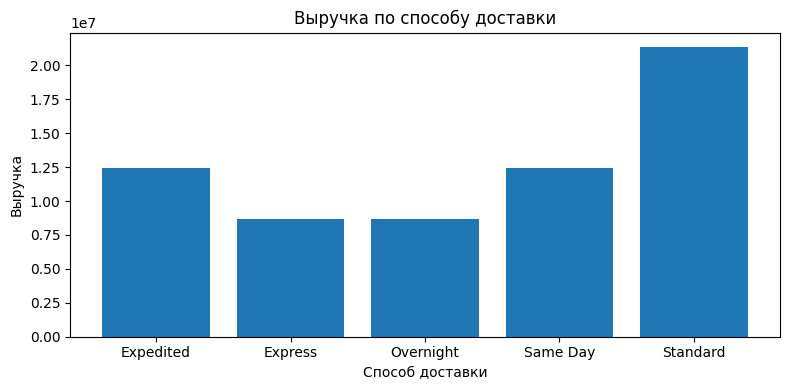

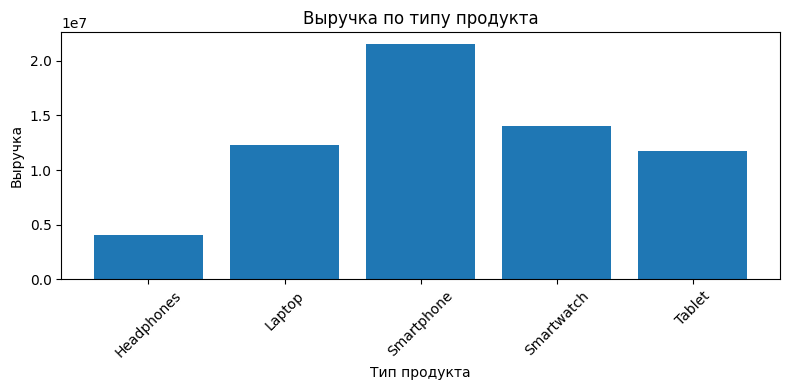

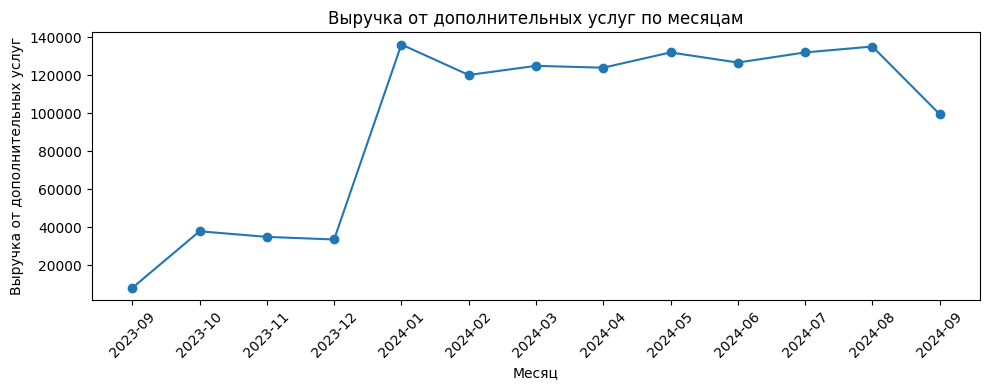

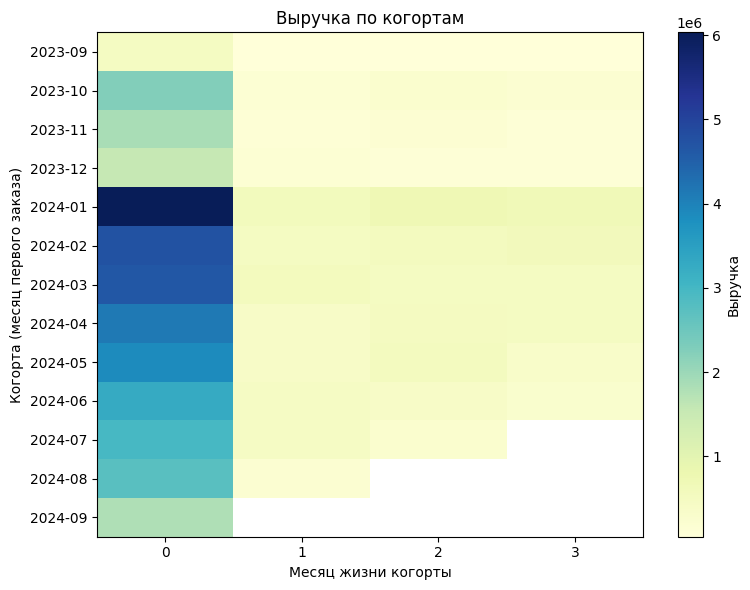

In [ ]:
import matplotlib.pyplot as plt

# bar выручка по способу доставки
# я так понял, что нужно по метрикам разложить, так что графика получилось 4, а не 3
shipping = metrics["revenue_by_shipping"]
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(
    shipping["shipping_method"],
    shipping["revenue"]
)
ax1.set_title("Выручка по способу доставки")
ax1.set_xlabel("Способ доставки")
ax1.set_ylabel("Выручка")
fig1.tight_layout()

# bar выручка по типу продукта
product_types = metrics["revenue_by_product_type"]
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(product_types["Product Type"], product_types["revenue"])
ax2.set_title("Выручка по типу продукта")
ax2.set_xlabel("Тип продукта")
ax2.set_ylabel("Выручка")
ax2.tick_params(axis="x", rotation=45)
fig2.tight_layout()

# line (доп. услуги по месяцам)
addons_by_month = metrics["addons_by_month"]
fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(
    addons_by_month["month"].astype(str),
    addons_by_month["addons_revenue"],
    marker="o"
)
ax3.set_title("Выручка от дополнительных услуг по месяцам")
ax3.set_xlabel("Месяц")
ax3.set_ylabel("Выручка от дополнительных услуг")
ax3.tick_params(axis="x", rotation=45)
fig3.tight_layout()

# heatmap когортной матрицы выручки
cohort_revenue = metrics["cohort_revenue"]
fig4, ax4 = plt.subplots(figsize=(8, 6))
heatmap = ax4.imshow(cohort_revenue, aspect="auto", cmap="YlGnBu")
ax4.set_title("Выручка по когортам")
ax4.set_xlabel("Месяц жизни когорты")
ax4.set_ylabel("Когорта (месяц первого заказа)")
ax4.set_xticks(range(len(cohort_revenue.columns)), cohort_revenue.columns)
ax4.set_yticks(range(len(cohort_revenue.index)), cohort_revenue.index.astype(str))
fig4.colorbar(heatmap, ax=ax4, label="Выручка")
fig4.tight_layout()

plt.show()